# RT-DETR-R18 — VisDrone Person Detection — Step 3

This notebook is a clean, self-contained Google Colab training pipeline.

It does **not** depend on any previous Step-2 folder layout.

Pipeline:

1. Validate the clean Colab scientific stack.
2. Install only the required project packages.
3. Mount Google Drive.
4. Clone the official RT-DETR repository.
5. Download VisDrone2019-DET **train + validation** directly from the official Ultralytics GitHub release assets.
6. Convert native VisDrone annotations to a **single person class**:
   - VisDrone category 1 `pedestrian` -> `person`
   - VisDrone category 2 `people` -> `person`
   - ignored regions are excluded
7. Build person-only COCO annotation JSON files.
8. Build a custom RT-DETR-R18 configuration.
9. Run a strict preflight.
10. Fine-tune the official RT-DETR-R18 COCO-pretrained checkpoint.
11. Save `last.pth`, `best.pth`, and an epoch-specific checkpoint after **every epoch** directly to Google Drive.
12. Automatically resume an interrupted run.
13. Generate Step-3 metrics, hashes, plots, and a final JSON report in Google Drive.

The private >=1000-image Final Test is **not used anywhere in this notebook**.


## 1. Clean Colab environment setup

In [1]:
# ============================================================
# STEP 3 - CLEAN COLAB ENVIRONMENT SETUP
# ============================================================

import sys
import subprocess

print("=" * 88)
print("CHECKING THE COLAB SCIENTIFIC STACK BEFORE INSTALLATION")
print("=" * 88)

# Validate the Colab-provided core stack before installing anything.
import numpy as np
import scipy
import torch
import torchvision

from scipy.special import expit

_ = expit(np.array([0.0, 1.0, 2.0]))

print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"SciPy       : {scipy.__version__}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print("NumPy/SciPy binary compatibility: PASSED")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. In Colab select Runtime > Change runtime type > GPU."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

print(f"GPU         : {gpu_name}")
print(f"GPU memory  : {gpu_memory_gb:.2f} GB")
print(f"CUDA        : {torch.version.cuda}")

if "L4" not in gpu_name.upper():
    raise RuntimeError(
        f"This controlled Step-3 experiment requires NVIDIA L4, but Colab assigned: {gpu_name}"
    )

print("\nInstalling only project dependencies...")
print("NumPy, SciPy, PyTorch and Torchvision will NOT be upgraded.")

packages = [
    "ultralytics>=8.4.114",
    "faster-coco-eval>=1.6.6",
    "pycocotools>=2.0.8",
    "PyYAML>=6.0",
    "tensorboard>=2.16",
    "tqdm>=4.66",
    "pillow>=10.0",
    "pandas>=2.0",
    "matplotlib>=3.7",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--disable-pip-version-check",
        *packages,
    ]
)

# Import after installation.
import ultralytics
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from pycocotools.coco import COCO

# Recheck the scientific stack after installation.
from scipy.special import expit
_ = expit(np.array([0.0, 1.0, 2.0]))

print("\n" + "=" * 88)
print("ENVIRONMENT READY")
print("=" * 88)
print(f"Ultralytics : {ultralytics.__version__}")
print("NumPy/SciPy compatibility after installation: PASSED")
print("NVIDIA L4 validation: PASSED")
print("=" * 88)


CHECKING THE COLAB SCIENTIFIC STACK BEFORE INSTALLATION
Python      : 3.12.13
NumPy       : 2.0.2
SciPy       : 1.16.3
PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
NumPy/SciPy binary compatibility: PASSED
GPU         : NVIDIA L4
GPU memory  : 22.03 GB
CUDA        : 12.8

Installing only project dependencies...
NumPy, SciPy, PyTorch and Torchvision will NOT be upgraded.
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

ENVIRONMENT READY
Ultralytics : 8.4.118
NumPy/SciPy compatibility after installation: PASSED
NVIDIA L4 validation: PASSED


## 2. Mount Google Drive and define the controlled experiment

In [2]:
# ============================================================
# GOOGLE DRIVE + CONTROLLED STEP-3 CONFIGURATION
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import os
import random
import time
import shutil
import hashlib
import json

# ------------------------- CONTROLLED BASELINE -------------------------
EPOCHS = 45
IMAGE_SIZE = 1280
BATCH_SIZE = 2
VAL_BATCH_SIZE = 2
WORKERS = 2
SEED = 42
USE_AMP = True
REQUIRE_L4 = True

# Keep the same run name to resume an interrupted run.
RUN_NAME = "rtdetr_r18_visdrone_person_45e_1280"

# Persistent Google Drive project root.
DRIVE_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/aerial_human_detection"
)

STEP3_ROOT = DRIVE_PROJECT_ROOT / "step3"
RUN_DIR = STEP3_ROOT / RUN_NAME
AUDIT_DIR = RUN_DIR / "audit"
REPORT_DIR = RUN_DIR / "reports"

for p in [STEP3_ROOT, RUN_DIR, AUDIT_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Fast local Colab storage.
LOCAL_ROOT = Path("/content/aerial_step3_rtdetr")
RAW_VISDRONE_ROOT = LOCAL_ROOT / "visdrone_raw"
LOCAL_COCO_ROOT = LOCAL_ROOT / "visdrone_person_coco"
REPO_ROOT = LOCAL_ROOT / "RT-DETR"
RTDETR_ROOT = REPO_ROOT / "rtdetrv2_pytorch"

for p in [LOCAL_ROOT, RAW_VISDRONE_ROOT, LOCAL_COCO_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Run directory:", RUN_DIR)
print("Epochs       :", EPOCHS)
print("Image size   :", IMAGE_SIZE)
print("Batch size   :", BATCH_SIZE)
print("Seed         :", SEED)
print("AMP          :", USE_AMP)
print("GPU          :", torch.cuda.get_device_name(0))


Mounted at /content/drive
Run directory: /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280
Epochs       : 45
Image size   : 1280
Batch size   : 2
Seed         : 42
AMP          : True
GPU          : NVIDIA L4


## 3. Clone the official RT-DETR repository with reproducible commit pinning

In [3]:
# ============================================================
# OFFICIAL RT-DETR SOURCE
# ============================================================

import subprocess

OFFICIAL_RTDETR_REPO = "https://github.com/lyuwenyu/RT-DETR.git"
COMMIT_FILE = AUDIT_DIR / "rtdetr_official_commit.txt"

if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

if COMMIT_FILE.exists():
    pinned_commit = COMMIT_FILE.read_text(encoding="utf-8").strip()
    print("Reusing pinned official RT-DETR commit:", pinned_commit)

    subprocess.check_call(
        ["git", "clone", "--filter=blob:none", "--no-checkout", OFFICIAL_RTDETR_REPO, str(REPO_ROOT)]
    )
    subprocess.check_call(
        ["git", "-C", str(REPO_ROOT), "fetch", "--depth", "1", "origin", pinned_commit]
    )
    subprocess.check_call(
        ["git", "-C", str(REPO_ROOT), "checkout", pinned_commit]
    )
else:
    print("Cloning the current official RT-DETR main branch...")
    subprocess.check_call(
        ["git", "clone", "--depth", "1", OFFICIAL_RTDETR_REPO, str(REPO_ROOT)]
    )
    pinned_commit = subprocess.check_output(
        ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"],
        text=True
    ).strip()
    COMMIT_FILE.write_text(pinned_commit + "\n", encoding="utf-8")
    print("Pinned official RT-DETR commit:", pinned_commit)

if not RTDETR_ROOT.exists():
    raise FileNotFoundError(
        f"Official RT-DETR PyTorch directory was not found: {RTDETR_ROOT}"
    )

print("Official repository:", OFFICIAL_RTDETR_REPO)
print("Pinned commit      :", pinned_commit)
print("Training code root :", RTDETR_ROOT)


Reusing pinned official RT-DETR commit: 199fc382f53abbfb5c1804c97b0e8b204e3cb8d0
Official repository: https://github.com/lyuwenyu/RT-DETR.git
Pinned commit      : 199fc382f53abbfb5c1804c97b0e8b204e3cb8d0
Training code root : /content/aerial_step3_rtdetr/RT-DETR/rtdetrv2_pytorch


## 4. Download VisDrone2019-DET train and validation from Ultralytics GitHub assets

In [4]:
# ============================================================
# OFFICIAL ULTRALYTICS VISDRONE DOWNLOAD
# ============================================================

from ultralytics.utils import ASSETS_URL
from ultralytics.utils.downloads import download

VISDRONE_TRAIN_URL = f"{ASSETS_URL}/VisDrone2019-DET-train.zip"
VISDRONE_VAL_URL = f"{ASSETS_URL}/VisDrone2019-DET-val.zip"

VISDRONE_URLS = [
    VISDRONE_TRAIN_URL,
    VISDRONE_VAL_URL,
]

TRAIN_SOURCE = RAW_VISDRONE_ROOT / "VisDrone2019-DET-train"
VAL_SOURCE = RAW_VISDRONE_ROOT / "VisDrone2019-DET-val"

print("Official Ultralytics GitHub asset URLs:")
for url in VISDRONE_URLS:
    print(" -", url)

if not (TRAIN_SOURCE.exists() and VAL_SOURCE.exists()):
    print("\nDownloading and extracting VisDrone2019-DET train + validation...")
    download(
        VISDRONE_URLS,
        dir=RAW_VISDRONE_ROOT,
        threads=2,
    )
else:
    print("VisDrone train/val already exist in this runtime.")

TRAIN_IMAGES = TRAIN_SOURCE / "images"
TRAIN_NATIVE_ANN = TRAIN_SOURCE / "annotations"
VAL_IMAGES = VAL_SOURCE / "images"
VAL_NATIVE_ANN = VAL_SOURCE / "annotations"

required_dirs = [
    TRAIN_IMAGES,
    TRAIN_NATIVE_ANN,
    VAL_IMAGES,
    VAL_NATIVE_ANN,
]

for p in required_dirs:
    if not p.exists():
        raise FileNotFoundError(f"Expected VisDrone directory not found: {p}")

train_image_files = sorted(TRAIN_IMAGES.glob("*.jpg"))
val_image_files = sorted(VAL_IMAGES.glob("*.jpg"))

print("\nVisDrone image counts:")
print(" Train:", len(train_image_files))
print(" Val  :", len(val_image_files))

# Official Ultralytics VisDrone split counts.
if len(train_image_files) != 6471:
    raise RuntimeError(
        f"Expected 6471 VisDrone train images, found {len(train_image_files)}."
    )

if len(val_image_files) != 548:
    raise RuntimeError(
        f"Expected 548 VisDrone validation images, found {len(val_image_files)}."
    )

dataset_source_record = {
    "dataset": "VisDrone2019-DET",
    "source": "Ultralytics GitHub release assets",
    "train_url": VISDRONE_TRAIN_URL,
    "val_url": VISDRONE_VAL_URL,
    "train_images": len(train_image_files),
    "val_images": len(val_image_files),
}
(AUDIT_DIR / "visdrone_source.json").write_text(
    json.dumps(dataset_source_record, indent=2),
    encoding="utf-8",
)

print("\nOfficial VisDrone download verification: PASSED")


Official Ultralytics GitHub asset URLs:
 - https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
 - https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip

Unzipping /content/aerial_step3_rtdetr/visdrone_raw/VisDrone2019-DET-val.zip to /content/aerial_step3_rtdetr/visdrone_raw/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 1.8Kfiles/s 0.6s
Unzipping /content/aerial_step3_rtdetr/visdrone_raw/VisDrone2019-DET-train.zip to /content/aerial_step3_rtdetr/visdrone_raw/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.7Kfiles/s 7.5s

VisDrone image counts:
 Train: 6471
 Val  : 548

Official VisDrone download verification: PASSED


## 5. Merge `pedestrian` + `people` into one `person` class and create COCO JSON

In [5]:
# ============================================================
# VISDRONE NATIVE -> PERSON-ONLY COCO
# ============================================================

from collections import Counter

# Native VisDrone object category IDs:
# 1 = pedestrian
# 2 = people
#
# Both are merged to:
# 0 = person
#
# Rows with score == 0 are ignored regions and are excluded.

PERSON_NATIVE_CATEGORIES = {1, 2}
PERSON_COCO_CATEGORY_ID = 0

TRAIN_COCO_JSON = LOCAL_COCO_ROOT / "instances_train_person.json"
VAL_COCO_JSON = LOCAL_COCO_ROOT / "instances_val_person.json"


def convert_visdrone_split_to_person_coco(
    images_dir: Path,
    annotations_dir: Path,
    output_json: Path,
    split_name: str,
):
    image_files = sorted(images_dir.glob("*.jpg"))

    coco_images = []
    coco_annotations = []
    source_category_counts = Counter()

    annotation_id = 1
    images_with_person = 0
    background_images = 0
    ignored_regions = 0
    invalid_rows = 0

    for image_id, image_path in enumerate(
        tqdm(image_files, desc=f"Converting {split_name}"),
        start=1,
    ):
        with Image.open(image_path) as im:
            width, height = im.size

        coco_images.append(
            {
                "id": image_id,
                "file_name": image_path.name,
                "width": int(width),
                "height": int(height),
            }
        )

        ann_path = annotations_dir / f"{image_path.stem}.txt"
        person_count_this_image = 0

        if not ann_path.exists():
            background_images += 1
            continue

        rows = [
            line.strip()
            for line in ann_path.read_text(
                encoding="utf-8-sig"
            ).splitlines()
            if line.strip()
        ]

        for row_index, row in enumerate(rows, start=1):
            fields = row.split(",")

            if len(fields) < 6:
                invalid_rows += 1
                continue

            try:
                x = float(fields[0])
                y = float(fields[1])
                w = float(fields[2])
                h = float(fields[3])
                score = int(float(fields[4]))
                category = int(float(fields[5]))
            except ValueError:
                invalid_rows += 1
                continue

            # VisDrone score=0 means an ignored region.
            if score == 0:
                ignored_regions += 1
                continue

            # Keep only pedestrian and people.
            if category not in PERSON_NATIVE_CATEGORIES:
                continue

            # Clip to valid image bounds.
            x = max(0.0, min(float(width), x))
            y = max(0.0, min(float(height), y))
            w = max(0.0, min(float(width) - x, w))
            h = max(0.0, min(float(height) - y, h))

            if w <= 0.0 or h <= 0.0:
                invalid_rows += 1
                continue

            coco_annotations.append(
                {
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": PERSON_COCO_CATEGORY_ID,
                    "bbox": [x, y, w, h],
                    "area": w * h,
                    "iscrowd": 0,
                }
            )

            annotation_id += 1
            person_count_this_image += 1
            source_category_counts[category] += 1

        if person_count_this_image > 0:
            images_with_person += 1
        else:
            background_images += 1

    payload = {
        "info": {
            "description": (
                f"VisDrone2019-DET {split_name} person-only dataset. "
                "Native categories pedestrian(1) and people(2) merged to person(0)."
            )
        },
        "licenses": [],
        "images": coco_images,
        "annotations": coco_annotations,
        "categories": [
            {
                "id": PERSON_COCO_CATEGORY_ID,
                "name": "person",
                "supercategory": "person",
            }
        ],
    }

    output_json.parent.mkdir(parents=True, exist_ok=True)
    output_json.write_text(
        json.dumps(payload, ensure_ascii=False),
        encoding="utf-8",
    )

    stats = {
        "split": split_name,
        "images": len(coco_images),
        "images_with_person": images_with_person,
        "background_images": background_images,
        "person_instances": len(coco_annotations),
        "native_pedestrian_instances": source_category_counts.get(1, 0),
        "native_people_instances": source_category_counts.get(2, 0),
        "ignored_regions_skipped": ignored_regions,
        "invalid_rows_skipped": invalid_rows,
        "output_json": str(output_json),
    }

    return stats


train_stats = convert_visdrone_split_to_person_coco(
    TRAIN_IMAGES,
    TRAIN_NATIVE_ANN,
    TRAIN_COCO_JSON,
    "train",
)

val_stats = convert_visdrone_split_to_person_coco(
    VAL_IMAGES,
    VAL_NATIVE_ANN,
    VAL_COCO_JSON,
    "val",
)

print("\nTrain statistics:")
print(json.dumps(train_stats, indent=2))

print("\nValidation statistics:")
print(json.dumps(val_stats, indent=2))

if train_stats["person_instances"] == 0:
    raise RuntimeError("No person annotations were produced for the training split.")

if val_stats["person_instances"] == 0:
    raise RuntimeError("No person annotations were produced for the validation split.")

# Persist conversion metadata and annotation JSON copies to Drive.
(AUDIT_DIR / "visdrone_person_conversion_stats.json").write_text(
    json.dumps(
        {"train": train_stats, "val": val_stats},
        indent=2,
    ),
    encoding="utf-8",
)

shutil.copy2(
    TRAIN_COCO_JSON,
    AUDIT_DIR / TRAIN_COCO_JSON.name,
)
shutil.copy2(
    VAL_COCO_JSON,
    AUDIT_DIR / VAL_COCO_JSON.name,
)

print("\nPerson-only COCO conversion: PASSED")


Converting train:   0%|          | 0/6471 [00:00<?, ?it/s]

Converting val:   0%|          | 0/548 [00:00<?, ?it/s]


Train statistics:
{
  "split": "train",
  "images": 6471,
  "images_with_person": 5684,
  "background_images": 787,
  "person_instances": 106396,
  "native_pedestrian_instances": 79337,
  "native_people_instances": 27059,
  "ignored_regions_skipped": 10345,
  "invalid_rows_skipped": 0,
  "output_json": "/content/aerial_step3_rtdetr/visdrone_person_coco/instances_train_person.json"
}

Validation statistics:
{
  "split": "val",
  "images": 548,
  "images_with_person": 531,
  "background_images": 17,
  "person_instances": 13969,
  "native_pedestrian_instances": 8844,
  "native_people_instances": 5125,
  "ignored_regions_skipped": 1410,
  "invalid_rows_skipped": 0,
  "output_json": "/content/aerial_step3_rtdetr/visdrone_person_coco/instances_val_person.json"
}

Person-only COCO conversion: PASSED


## 6. Strict dataset audit

In [6]:
# ============================================================
# STRICT PERSON-ONLY COCO AUDIT
# ============================================================

def audit_person_coco(
    annotation_file: Path,
    image_dir: Path,
    expected_images: int,
    split_name: str,
):
    data = json.loads(
        annotation_file.read_text(encoding="utf-8")
    )

    categories = data.get("categories", [])
    images = data.get("images", [])
    annotations = data.get("annotations", [])

    if categories != [
        {
            "id": 0,
            "name": "person",
            "supercategory": "person",
        }
    ]:
        raise RuntimeError(
            f"{split_name}: categories are not exactly person-only class 0."
        )

    if len(images) != expected_images:
        raise RuntimeError(
            f"{split_name}: expected {expected_images} images, found {len(images)}."
        )

    bad_category_ids = sorted(
        {
            ann.get("category_id")
            for ann in annotations
            if ann.get("category_id") != 0
        }
    )
    if bad_category_ids:
        raise RuntimeError(
            f"{split_name}: unexpected category IDs: {bad_category_ids}"
        )

    missing_images = []
    for item in images:
        p = image_dir / item["file_name"]
        if not p.exists():
            missing_images.append(str(p))
            if len(missing_images) >= 10:
                break

    if missing_images:
        raise FileNotFoundError(
            f"{split_name}: missing image files. Examples: {missing_images}"
        )

    for ann in annotations[: min(5000, len(annotations))]:
        x, y, w, h = ann["bbox"]
        if w <= 0 or h <= 0:
            raise RuntimeError(
                f"{split_name}: invalid non-positive bounding box detected."
            )

    # pycocotools structural validation.
    coco = COCO(str(annotation_file))

    return {
        "split": split_name,
        "images": len(images),
        "annotations": len(annotations),
        "categories": coco.getCatIds(),
    }


train_audit = audit_person_coco(
    TRAIN_COCO_JSON,
    TRAIN_IMAGES,
    6471,
    "train",
)

val_audit = audit_person_coco(
    VAL_COCO_JSON,
    VAL_IMAGES,
    548,
    "val",
)

print("Train audit:", train_audit)
print("Val audit  :", val_audit)
print("\nSTRICT DATASET AUDIT: PASSED")


loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Train audit: {'split': 'train', 'images': 6471, 'annotations': 106396, 'categories': [0]}
Val audit  : {'split': 'val', 'images': 548, 'annotations': 13969, 'categories': [0]}

STRICT DATASET AUDIT: PASSED


## 7. Build the RT-DETR-R18 VisDrone person-only configuration

In [7]:
import textwrap

# ============================================================
# CUSTOM RT-DETR-R18 CONFIGURATION
# ============================================================

CONFIG_DIR = RTDETR_ROOT / "configs" / "custom"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = CONFIG_DIR / "rtdetr_r18_visdrone_person_45e_1280.yml"

config_text = f"""
__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

output_dir: {str(RUN_DIR)}

num_classes: 1
remap_mscoco_category: False

epoches: {EPOCHS}
checkpoint_freq: 1
print_freq: 20

use_ema: True
use_amp: True

# Fixed controlled input resolution.
eval_spatial_size: [{IMAGE_SIZE}, {IMAGE_SIZE}]

# The full COCO-pretrained RT-DETR-R18 checkpoint is loaded through --tuning.
# Therefore an additional ImageNet backbone download is unnecessary.
PResNet:
  pretrained: False

train_dataloader:
  dataset:
    img_folder: {str(TRAIN_IMAGES)}
    ann_file: {str(TRAIN_COCO_JSON)}
    return_masks: False
    transforms:
      type: Compose
      ops:
        - {{type: RandomPhotometricDistort, p: 0.5}}
        - {{type: RandomZoomOut, fill: 0}}
        - {{type: RandomIoUCrop, p: 0.8}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: RandomHorizontalFlip}}
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}
        - {{type: ConvertBoxes, fmt: 'cxcywh', normalize: True}}
  shuffle: True
  num_workers: {WORKERS}
  drop_last: True
  total_batch_size: {BATCH_SIZE}
  collate_fn:
    type: BatchImageCollateFunction
    scales: [{IMAGE_SIZE}]

val_dataloader:
  dataset:
    img_folder: {str(VAL_IMAGES)}
    ann_file: {str(VAL_COCO_JSON)}
    return_masks: False
    transforms:
      type: Compose
      ops:
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}
  shuffle: False
  num_workers: {WORKERS}
  drop_last: False
  total_batch_size: {VAL_BATCH_SIZE}
  collate_fn:
    type: BatchImageCollateFunction
"""

CONFIG_PATH.write_text(
    textwrap.dedent(config_text).strip() + "\n",
    encoding="utf-8",
)

shutil.copy2(
    CONFIG_PATH,
    AUDIT_DIR / CONFIG_PATH.name,
)

print(CONFIG_PATH.read_text(encoding="utf-8"))
print("Custom configuration written to:", CONFIG_PATH)


__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

output_dir: /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280

num_classes: 1
remap_mscoco_category: False

epoches: 45
checkpoint_freq: 1
print_freq: 20

use_ema: True
use_amp: True

# Fixed controlled input resolution.
eval_spatial_size: [1280, 1280]

# The full COCO-pretrained RT-DETR-R18 checkpoint is loaded through --tuning.
# Therefore an additional ImageNet backbone download is unnecessary.
PResNet:
  pretrained: False

train_dataloader:
  dataset:
    img_folder: /content/aerial_step3_rtdetr/visdrone_raw/VisDrone2019-DET-train/images
    ann_file: /content/aerial_step3_rtdetr/visdrone_person_coco/instances_train_person.json
    return_masks: False
    transforms:
      type: Compose
      ops:
        - {type: RandomPhotometricDistort, p: 0.5}
        - {type: RandomZoomOut, fill: 0}
        - {type: RandomIoUCrop, p: 0.8}
        - {type: SanitizeBoundingBoxes, min_size: 1}
        - {ty

## 8. Official RT-DETR-R18 pretrained checkpoint and model preflight

In [8]:
# ============================================================
# OFFICIAL RT-DETR-R18 MODEL PREFLIGHT
# ============================================================

# Official RT-DETR-R18 COCO-pretrained PyTorch checkpoint referenced by
# the official RT-DETR GitHub hubconf.py.
PRETRAINED_R18_URL = (
    "https://github.com/lyuwenyu/storage/releases/download/"
    "v0.1/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth"
)

print("Official RT-DETR repository:")
print(OFFICIAL_RTDETR_REPO)

print("\nOfficial RT-DETR-R18 COCO checkpoint:")
print(PRETRAINED_R18_URL)

# Save the model-source record.
model_source_record = {
    "architecture": "RT-DETR-R18",
    "official_repository": OFFICIAL_RTDETR_REPO,
    "repository_commit": pinned_commit,
    "pretrained_checkpoint": PRETRAINED_R18_URL,
    "pretrained_dataset": "COCO",
    "target_dataset": "VisDrone2019-DET person-only",
    "target_classes": ["person"],
    "visdrone_native_classes_merged": {
        "1": "pedestrian -> person",
        "2": "people -> person",
    },
}
(AUDIT_DIR / "model_source.json").write_text(
    json.dumps(model_source_record, indent=2),
    encoding="utf-8",
)

# Import the official configuration system and build the model on CPU.
import gc

old_cwd = Path.cwd()
os.chdir(RTDETR_ROOT)

if str(RTDETR_ROOT) not in sys.path:
    sys.path.insert(0, str(RTDETR_ROOT))

from src.core import YAMLConfig

cfg = YAMLConfig(
    str(CONFIG_PATH),
    device="cpu",
    use_amp=False,
    output_dir=str(RUN_DIR),
)

if cfg.yaml_cfg.get("num_classes") != 1:
    raise RuntimeError(
        f"Expected num_classes=1, got {cfg.yaml_cfg.get('num_classes')}"
    )

if cfg.yaml_cfg.get("remap_mscoco_category") is not False:
    raise RuntimeError(
        "remap_mscoco_category must be False for the custom person-only dataset."
    )

model = cfg.model
trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Model build: PASSED")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Configured classes:", cfg.yaml_cfg["num_classes"])
print("Configured epochs :", cfg.yaml_cfg["epoches"])

del model
del cfg
gc.collect()
torch.cuda.empty_cache()

os.chdir(old_cwd)

print("\nOFFICIAL MODEL + CONFIG PREFLIGHT: PASSED")


Official RT-DETR repository:
https://github.com/lyuwenyu/RT-DETR.git

Official RT-DETR-R18 COCO checkpoint:
https://github.com/lyuwenyu/storage/releases/download/v0.1/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth


/content/aerial_step3_rtdetr/RT-DETR/rtdetrv2_pytorch/src/misc/profiler_utils.py:58: SyntaxWarning: invalid escape sequence '\d'
  num_flops = sum([float(v.strip()) for v in re.findall('(\d+.?\d+ *\n)', info)]) / num_active


Model build: PASSED
Trainable parameters: 20,083,028
Configured classes: 1
Configured epochs : 45

OFFICIAL MODEL + CONFIG PREFLIGHT: PASSED


## 9. One-batch dataloader preflight

In [9]:
# ============================================================
# ONE-BATCH DATA PIPELINE PREFLIGHT
# ============================================================

import gc

old_cwd = Path.cwd()
os.chdir(RTDETR_ROOT)

from src.core import YAMLConfig

cfg = YAMLConfig(
    str(CONFIG_PATH),
    device="cpu",
    use_amp=False,
    output_dir=str(RUN_DIR),
)

train_loader = cfg.train_dataloader
val_loader = cfg.val_dataloader

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

train_batch = next(iter(train_loader))

# The official collate function returns image tensors and target dictionaries.
images, targets = train_batch

print("Train batch image tensor shape:", tuple(images.shape))
print("Targets in batch:", len(targets))

if images.shape[0] != BATCH_SIZE:
    raise RuntimeError(
        f"Expected training batch size {BATCH_SIZE}, got {images.shape[0]}."
    )

if images.shape[-2:] != (IMAGE_SIZE, IMAGE_SIZE):
    raise RuntimeError(
        f"Expected {IMAGE_SIZE}x{IMAGE_SIZE}, got {tuple(images.shape[-2:])}."
    )

for idx, target in enumerate(targets):
    labels = target.get("labels")
    if labels is not None and labels.numel() > 0:
        bad = labels[labels != 0]
        if bad.numel() > 0:
            raise RuntimeError(
                f"Non-person label detected in target {idx}: {bad.tolist()}"
            )

del train_batch
del train_loader
del val_loader
del cfg
gc.collect()
torch.cuda.empty_cache()

os.chdir(old_cwd)

print("\nONE-BATCH DATA PIPELINE PREFLIGHT: PASSED")


building train_dataloader with batch_size=2...
building val_dataloader with batch_size=2...
Train batches: 3235
Val batches  : 274
Train batch image tensor shape: (2, 3, 1280, 1280)
Targets in batch: 2

ONE-BATCH DATA PIPELINE PREFLIGHT: PASSED


## 10. Train or automatically resume RT-DETR-R18

In [10]:
# ============================================================
# FINAL RT-DETR-R18 TRAINING / RESUME CELL
# VisDrone Person Detection
#
# Features:
#   - Official COCO pretrained checkpoint
#   - Automatic resume from last.pth
#   - Clean report only after each completed epoch
#   - Train loss
#   - Validation COCO metrics
#   - Epoch time
#   - Best validation mAP
#   - Persistent checkpoints in Google Drive
#
# IMPORTANT:
#   Old epoch-specific checkpoint files may be deleted.
#   Resume depends on last.pth, not on checkpoint000X.pth files.
#
# Files that should NOT be deleted:
#   - last.pth
#   - best.pth
#   - log.txt
#
# ============================================================

from pathlib import Path
from collections import deque

import gc
import hashlib
import json
import os
import subprocess
import sys
import threading
import time

import torch


# ============================================================
# 1. OFFICIAL RT-DETR-R18 PRETRAINED CHECKPOINT
# ============================================================

PRETRAINED_R18_URL = (
    "https://github.com/lyuwenyu/storage/releases/download/"
    "v0.1/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth"
)

PRETRAINED_DIR = (
    DRIVE_PROJECT_ROOT
    / "pretrained"
    / "rtdetr"
)

PRETRAINED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PRETRAINED_R18_PATH = (
    PRETRAINED_DIR
    / "rtdetr_r18vd_dec3_6x_coco_from_paddle.pth"
)

TEMP_DOWNLOAD_PATH = (
    PRETRAINED_DIR
    / "rtdetr_r18vd_dec3_6x_coco_from_paddle.pth.part"
)

MIN_CHECKPOINT_SIZE_BYTES = 50 * 1024 * 1024


print("=" * 88)
print("RT-DETR-R18 PRETRAINED CHECKPOINT")
print("=" * 88)

print("Official source:")
print(PRETRAINED_R18_URL)

print("\nPersistent target:")
print(PRETRAINED_R18_PATH)


# ============================================================
# 2. CHECK / DOWNLOAD PRETRAINED WEIGHTS
# ============================================================

download_required = True

if PRETRAINED_R18_PATH.exists():

    existing_size = PRETRAINED_R18_PATH.stat().st_size

    print(
        f"\nExisting checkpoint: "
        f"{existing_size / 1024 / 1024:.2f} MiB"
    )

    if existing_size >= MIN_CHECKPOINT_SIZE_BYTES:

        download_required = False

        print(
            "Existing pretrained checkpoint looks valid."
        )

    else:

        print(
            "Incomplete pretrained checkpoint detected. "
            "Removing it."
        )

        PRETRAINED_R18_PATH.unlink()


if TEMP_DOWNLOAD_PATH.exists():

    TEMP_DOWNLOAD_PATH.unlink()


if download_required:

    print("\n" + "=" * 88)
    print("DOWNLOADING OFFICIAL PRETRAINED WEIGHTS")
    print("=" * 88)

    download_result = subprocess.run(
        [
            "wget",
            "--progress=bar:force:noscroll",
            "--tries=5",
            "--timeout=60",
            "-O",
            str(TEMP_DOWNLOAD_PATH),
            PRETRAINED_R18_URL,
        ]
    )

    if download_result.returncode != 0:

        raise RuntimeError(
            "Failed to download the official "
            "RT-DETR-R18 pretrained checkpoint."
        )

    if not TEMP_DOWNLOAD_PATH.exists():

        raise FileNotFoundError(
            "Downloaded checkpoint file was not created."
        )

    downloaded_size = TEMP_DOWNLOAD_PATH.stat().st_size

    print(
        f"Downloaded size: "
        f"{downloaded_size / 1024 / 1024:.2f} MiB"
    )

    if downloaded_size < MIN_CHECKPOINT_SIZE_BYTES:

        raise RuntimeError(
            "Downloaded pretrained checkpoint "
            "is unexpectedly small."
        )

    TEMP_DOWNLOAD_PATH.replace(
        PRETRAINED_R18_PATH
    )


# ============================================================
# 3. VERIFY PRETRAINED CHECKPOINT
# ============================================================

print("\nVerifying pretrained checkpoint...")


def sha256_file(path: Path):

    hasher = hashlib.sha256()

    with path.open("rb") as file:

        while True:

            block = file.read(
                1024 * 1024
            )

            if not block:
                break

            hasher.update(block)

    return hasher.hexdigest()


checkpoint_size = PRETRAINED_R18_PATH.stat().st_size

print(
    f"Checkpoint size: "
    f"{checkpoint_size / 1024 / 1024:.2f} MiB"
)

print(
    "SHA256:",
    sha256_file(
        PRETRAINED_R18_PATH
    ),
)


try:

    pretrained_state = torch.load(
        PRETRAINED_R18_PATH,
        map_location="cpu",
        weights_only=False,
    )

except Exception as exc:

    raise RuntimeError(
        "PyTorch cannot load the pretrained checkpoint."
    ) from exc


if not isinstance(
    pretrained_state,
    dict,
):

    raise RuntimeError(
        "Unexpected pretrained checkpoint format."
    )


print(
    "Checkpoint keys:",
    list(
        pretrained_state.keys()
    ),
)

del pretrained_state

gc.collect()

print(
    "PRETRAINED CHECKPOINT VERIFICATION: PASSED"
)


# ============================================================
# 4. TRAINING PATHS
# ============================================================

TRAIN_SCRIPT = (
    RTDETR_ROOT
    / "tools"
    / "train.py"
)

LAST_CHECKPOINT = (
    RUN_DIR
    / "last.pth"
)

BEST_CHECKPOINT = (
    RUN_DIR
    / "best.pth"
)

LOG_FILE = (
    RUN_DIR
    / "log.txt"
)


if not TRAIN_SCRIPT.exists():

    raise FileNotFoundError(
        f"Training script not found:\n{TRAIN_SCRIPT}"
    )


RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 5. READ EXISTING TRAINING STATE
# ============================================================

resume_epoch = None


if LAST_CHECKPOINT.exists():

    try:

        state = torch.load(
            LAST_CHECKPOINT,
            map_location="cpu",
            weights_only=False,
        )

        resume_epoch = int(
            state.get(
                "last_epoch",
                -1,
            )
        )

        del state

        gc.collect()

    except Exception as exc:

        raise RuntimeError(
            "last.pth exists but cannot be loaded."
        ) from exc


    print("\n" + "=" * 88)
    print("RESUME CHECKPOINT DETECTED")
    print("=" * 88)

    print(
        "Checkpoint:",
        LAST_CHECKPOINT,
    )

    print(
        "Completed epochs:",
        resume_epoch + 1,
        "/",
        EPOCHS,
    )


# ============================================================
# 6. READ TRAINING LOG
# ============================================================

def read_log_records():

    records = []

    if not LOG_FILE.exists():
        return records

    try:

        lines = LOG_FILE.read_text(
            encoding="utf-8"
        ).splitlines()

    except Exception:
        return records


    for line in lines:

        line = line.strip()

        if not line:
            continue

        try:

            record = json.loads(
                line
            )

        except Exception:
            continue


        if "epoch" in record:

            records.append(
                record
            )

    return records


existing_records = read_log_records()


seen_epochs = {

    int(record["epoch"])

    for record in existing_records
}


# ============================================================
# 7. FIND EXISTING BEST VALIDATION mAP
# ============================================================

best_map = 0.0


for record in existing_records:

    stats = record.get(
        "test_coco_eval_bbox"
    )

    if (
        isinstance(
            stats,
            list,
        )
        and len(stats) >= 1
    ):

        try:

            best_map = max(
                best_map,
                float(
                    stats[0]
                ),
            )

        except Exception:
            pass


# ============================================================
# 8. TIME FORMATTER
# ============================================================

def format_time(seconds):

    seconds = int(
        max(
            0,
            seconds,
        )
    )

    hours = seconds // 3600

    minutes = (
        seconds % 3600
    ) // 60

    secs = seconds % 60

    return (
        f"{hours:02d}:"
        f"{minutes:02d}:"
        f"{secs:02d}"
    )


# ============================================================
# 9. EPOCH-END REPORT FUNCTION
# ============================================================

training_start_time = None
previous_epoch_end_time = None


def report_new_epochs():

    global best_map
    global previous_epoch_end_time

    records = read_log_records()

    for record in records:

        epoch_zero_based = int(
            record["epoch"]
        )

        if epoch_zero_based in seen_epochs:
            continue


        seen_epochs.add(
            epoch_zero_based
        )


        current_time = time.time()


        if previous_epoch_end_time is None:

            epoch_time = (
                current_time
                - training_start_time
            )

        else:

            epoch_time = (
                current_time
                - previous_epoch_end_time
            )


        previous_epoch_end_time = (
            current_time
        )


        epoch_number = (
            epoch_zero_based
            + 1
        )


        # ----------------------------------------------------
        # TRAIN LOSS
        # ----------------------------------------------------

        train_loss = record.get(
            "train_loss"
        )


        # ----------------------------------------------------
        # VALIDATION COCO METRICS
        # ----------------------------------------------------

        coco_stats = record.get(
            "test_coco_eval_bbox"
        )


        map_50_95 = None
        ap50 = None
        ap75 = None
        ap_small = None
        ap_medium = None
        ap_large = None
        ar100 = None


        if (
            isinstance(
                coco_stats,
                list,
            )
            and len(coco_stats) >= 12
        ):

            map_50_95 = float(
                coco_stats[0]
            )

            ap50 = float(
                coco_stats[1]
            )

            ap75 = float(
                coco_stats[2]
            )

            ap_small = float(
                coco_stats[3]
            )

            ap_medium = float(
                coco_stats[4]
            )

            ap_large = float(
                coco_stats[5]
            )

            ar100 = float(
                coco_stats[8]
            )


        if map_50_95 is not None:

            best_map = max(
                best_map,
                map_50_95,
            )


        # ----------------------------------------------------
        # CHECKPOINT STATUS
        # ----------------------------------------------------

        epoch_checkpoint_candidates = sorted(
            RUN_DIR.glob(
                f"checkpoint*{epoch_zero_based:04d}*.pth"
            )
        )


        if epoch_checkpoint_candidates:

            checkpoint_status = "SAVED"

        elif LAST_CHECKPOINT.exists():

            checkpoint_status = "LAST.PTH SAVED"

        else:

            checkpoint_status = "CHECKING"


        # ----------------------------------------------------
        # CLEAN REPORT
        # ----------------------------------------------------

        print(
            "\n"
            + "=" * 72,
            flush=True,
        )

        print(
            f"EPOCH {epoch_number:02d} / "
            f"{EPOCHS:02d} COMPLETED",
            flush=True,
        )

        print(
            "=" * 72,
            flush=True,
        )


        if train_loss is not None:

            print(
                f"Train Loss          : "
                f"{float(train_loss):.6f}",
                flush=True,
            )


        if map_50_95 is not None:

            print(
                f"Validation mAP50-95 : "
                f"{map_50_95:.6f}",
                flush=True,
            )

            print(
                f"Validation AP50     : "
                f"{ap50:.6f}",
                flush=True,
            )

            print(
                f"Validation AP75     : "
                f"{ap75:.6f}",
                flush=True,
            )

            print(
                f"Validation AP Small : "
                f"{ap_small:.6f}",
                flush=True,
            )

            print(
                f"Validation AP Medium: "
                f"{ap_medium:.6f}",
                flush=True,
            )

            print(
                f"Validation AP Large : "
                f"{ap_large:.6f}",
                flush=True,
            )

            print(
                f"Validation AR100    : "
                f"{ar100:.6f}",
                flush=True,
            )

            print(
                f"Best mAP50-95       : "
                f"{best_map:.6f}",
                flush=True,
            )


        print(
            f"Epoch Time          : "
            f"{format_time(epoch_time)}",
            flush=True,
        )

        print(
            f"Total Session Time  : "
            f"{format_time(current_time - training_start_time)}",
            flush=True,
        )

        print(
            f"Checkpoint          : "
            f"{checkpoint_status}",
            flush=True,
        )

        print(
            "=" * 72
            + "\n",
            flush=True,
        )


# ============================================================
# 10. BACKGROUND EPOCH REPORTER
# ============================================================

stop_reporter = threading.Event()


def epoch_reporter():

    while not stop_reporter.is_set():

        report_new_epochs()

        stop_reporter.wait(
            3
        )


# ============================================================
# 11. CHECK WHETHER TRAINING IS ALREADY COMPLETE
# ============================================================

training_already_complete = (

    resume_epoch is not None

    and

    resume_epoch >= EPOCHS - 1
)


# ============================================================
# 12. BUILD TRAINING COMMAND
# ============================================================

if training_already_complete:

    print("\n" + "=" * 88)
    print("TRAINING ALREADY COMPLETE")
    print("=" * 88)

    print(
        f"Completed epochs: "
        f"{resume_epoch + 1}/{EPOCHS}"
    )


else:

    command = [

        sys.executable,

        "-u",

        str(
            TRAIN_SCRIPT
        ),

        "-c",

        str(
            CONFIG_PATH
        ),

        "--seed",

        str(
            SEED
        ),

        "--device",

        "cuda",

        "--output-dir",

        str(
            RUN_DIR
        ),

        "--summary-dir",

        str(
            RUN_DIR
            / "summary"
        ),
    ]


    if USE_AMP:

        command.append(
            "--use-amp"
        )


    # ========================================================
    # RESUME MODE
    # ========================================================

    if LAST_CHECKPOINT.exists():

        command += [

            "--resume",

            str(
                LAST_CHECKPOINT
            ),
        ]

        training_mode = "RESUME"


        print(
            f"\nTraining will resume from "
            f"epoch {resume_epoch + 2}/{EPOCHS}."
        )


    # ========================================================
    # FRESH FINE-TUNING MODE
    # ========================================================

    else:

        command += [

            "--tuning",

            str(
                PRETRAINED_R18_PATH
            ),
        ]

        training_mode = (
            "COCO PRETRAINED FINE-TUNING"
        )


    # ========================================================
    # 13. TRAINING SUMMARY
    # ========================================================

    print("\n" + "=" * 88)
    print("ACTUAL RT-DETR-R18 TRAINING LAUNCH")
    print("=" * 88)

    print(
        "Architecture   : RT-DETR-R18"
    )

    print(
        "Initialization :",
        training_mode,
    )

    print(
        "Dataset        : VisDrone2019-DET"
    )

    print(
        "Target class   : person"
    )

    print(
        "Epochs         :",
        EPOCHS,
    )

    print(
        "Input size     :",
        f"{IMAGE_SIZE} x {IMAGE_SIZE}",
    )

    print(
        "Batch size     :",
        BATCH_SIZE,
    )

    print(
        "AMP            :",
        USE_AMP,
    )

    print(
        "Seed           :",
        SEED,
    )

    print(
        "GPU            :",
        torch.cuda.get_device_name(
            0
        ),
    )

    print(
        "Output         :",
        RUN_DIR,
    )

    print(
        "Epoch reporting: "
        "after each completed epoch"
    )

    print(
        "Old checkpoints: "
        "may be deleted safely"
    )

    print(
        "Resume source  : last.pth"
    )

    print("=" * 88)

    print(
        "\nTraining started. "
        "The next report will appear after "
        "the current epoch and validation finish.\n"
    )


    # ========================================================
    # 14. TRAINING ENVIRONMENT
    # ========================================================

    env = os.environ.copy()

    env[
        "PYTHONUNBUFFERED"
    ] = "1"

    env[
        "CUDA_VISIBLE_DEVICES"
    ] = "0"


    torch.cuda.empty_cache()


    training_start_time = (
        time.time()
    )

    previous_epoch_end_time = (
        training_start_time
    )


    # ========================================================
    # 15. START EPOCH REPORTER
    # ========================================================

    reporter_thread = threading.Thread(
        target=epoch_reporter,
        daemon=True,
    )

    reporter_thread.start()


    # ========================================================
    # 16. START OFFICIAL RT-DETR TRAINING
    # ========================================================

    recent_output = deque(
        maxlen=150
    )


    process = subprocess.Popen(

        command,

        cwd=str(
            RTDETR_ROOT
        ),

        env=env,

        stdout=subprocess.PIPE,

        stderr=subprocess.STDOUT,

        text=True,

        bufsize=1,
    )


    try:

        for line in process.stdout:

            clean_line = (
                line.rstrip()
            )

            recent_output.append(
                clean_line
            )


            # Keep normal batch logs hidden.
            # Show only critical diagnostic messages.

            low = (
                clean_line.lower()
            )


            critical_patterns = (

                "traceback",

                "runtimeerror",

                "exception",

                "cuda out of memory",

                "nan detected",

                "fatal",
            )


            if any(
                pattern in low
                for pattern in critical_patterns
            ):

                print(
                    clean_line,
                    flush=True,
                )


        return_code = (
            process.wait()
        )


    # ========================================================
    # SAFE MANUAL STOP
    # ========================================================

    except KeyboardInterrupt:

        print("\n" + "=" * 88)

        print(
            "MANUAL TRAINING STOP REQUESTED"
        )

        print("=" * 88)

        print(
            "Stopping the current training process..."
        )


        process.terminate()


        try:

            process.wait(
                timeout=20
            )

        except subprocess.TimeoutExpired:

            process.kill()


        # Process any final completed epoch
        # that may have reached log.txt before stopping.

        time.sleep(
            2
        )

        report_new_epochs()


        print(
            "\nThe last fully completed epoch "
            "stored in last.pth will be used "
            "automatically when this cell is "
            "run again."
        )

        print(
            "\nIMPORTANT:"
        )

        print(
            "Keep last.pth, best.pth and log.txt."
        )

        print(
            "Older checkpointXXXX.pth files "
            "may be deleted."
        )


        raise


    finally:

        # Give the official process a moment
        # to finish writing log.txt.

        time.sleep(
            2
        )

        report_new_epochs()

        stop_reporter.set()

        reporter_thread.join(
            timeout=10
        )


    # ========================================================
    # 17. PROCESS RETURN CODE CHECK
    # ========================================================

    if return_code != 0:

        print(
            "\nLast RT-DETR diagnostic lines:"
        )

        for line in recent_output:

            print(
                line
            )


        raise RuntimeError(
            f"RT-DETR training exited "
            f"with code {return_code}. "
            "Run this same cell again to resume "
            "from last.pth."
        )


# ============================================================
# 18. CURRENT TRAINING STATE VERIFICATION
# ============================================================

if not LAST_CHECKPOINT.exists():

    raise RuntimeError(
        "last.pth does not exist. "
        "A resumable training state was not found."
    )


final_state = torch.load(
    LAST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)


last_epoch = int(
    final_state.get(
        "last_epoch",
        -1,
    )
)


del final_state

gc.collect()


completed_epochs = (
    last_epoch + 1
)


print("\n" + "=" * 88)
print("CURRENT TRAINING STATE")
print("=" * 88)

print(
    "Completed epochs:",
    f"{completed_epochs}/{EPOCHS}",
)

print(
    "Resume checkpoint:",
    LAST_CHECKPOINT,
)


if BEST_CHECKPOINT.exists():

    print(
        "Best checkpoint:",
        BEST_CHECKPOINT,
    )

else:

    print(
        "Best checkpoint: "
        "not available yet"
    )


if LOG_FILE.exists():

    print(
        "Training log:",
        LOG_FILE,
    )

else:

    print(
        "Training log: "
        "not available yet"
    )


# ============================================================
# 19. EPOCH-SPECIFIC CHECKPOINT INFORMATION
# ============================================================

epoch_checkpoints = sorted(
    RUN_DIR.glob(
        "checkpoint*.pth"
    )
)


print(
    "Available epoch-specific checkpoints:",
    len(
        epoch_checkpoints
    ),
)


if epoch_checkpoints:

    print(
        "Latest epoch-specific checkpoint:",
        epoch_checkpoints[-1],
    )


print(
    "\nNOTE:"
)

print(
    "Missing old checkpointXXXX.pth files "
    "do NOT prevent resume."
)

print(
    "Resume uses last.pth."
)


# ============================================================
# 20. FINAL STATUS
# ============================================================

if completed_epochs >= EPOCHS:

    if not BEST_CHECKPOINT.exists():

        raise RuntimeError(
            "Training reached the target number "
            "of epochs but best.pth was not found."
        )


    if not LOG_FILE.exists():

        raise RuntimeError(
            "Training reached the target number "
            "of epochs but log.txt was not found."
        )


    print("\n" + "=" * 88)
    print("RT-DETR-R18 TRAINING COMPLETED SUCCESSFULLY")
    print("=" * 88)

    print(
        "Dataset    : VisDrone2019-DET"
    )

    print(
        "Class      : person"
    )

    print(
        "Epochs     :",
        completed_epochs,
    )

    print(
        "Best model :",
        BEST_CHECKPOINT,
    )

    print(
        "Last model :",
        LAST_CHECKPOINT,
    )

    print(
        "Run folder :",
        RUN_DIR,
    )

    print("=" * 88)


else:

    print("\n" + "=" * 88)
    print("TRAINING CAN BE RESUMED")
    print("=" * 88)

    print(
        f"Completed: "
        f"{completed_epochs}/{EPOCHS} epochs"
    )

    print(
        f"Remaining: "
        f"{EPOCHS - completed_epochs} epochs"
    )

    print(
        "Run this same cell again "
        "to continue automatically."
    )

    print("=" * 88)

RT-DETR-R18 PRETRAINED CHECKPOINT
Official source:
https://github.com/lyuwenyu/storage/releases/download/v0.1/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth

Persistent target:
/content/drive/MyDrive/aerial_human_detection/pretrained/rtdetr/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth

Existing checkpoint: 77.25 MiB
Existing pretrained checkpoint looks valid.

Verifying pretrained checkpoint...
Checkpoint size: 77.25 MiB
SHA256: 3ba8b5c909c9a1c4f21e96d0a7251ab1a485093955ca327d0061fef8d33c66f0
Checkpoint keys: ['ema']
PRETRAINED CHECKPOINT VERIFICATION: PASSED

RESUME CHECKPOINT DETECTED
Checkpoint: /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280/last.pth
Completed epochs: 28 / 45

Training will resume from epoch 29/45.

ACTUAL RT-DETR-R18 TRAINING LAUNCH
Architecture   : RT-DETR-R18
Initialization : RESUME
Dataset        : VisDrone2019-DET
Target class   : person
Epochs         : 45
Input size     : 1280 x 1280
Batch size     : 2
AMP            : True
Se

## 11. Build Step-3 metrics, plots, hashes, and final report

Logged epochs: 45
Columns:
['train_lr', 'train_loss', 'train_loss_vfl', 'train_loss_bbox', 'train_loss_giou', 'train_loss_vfl_aux_0', 'train_loss_bbox_aux_0', 'train_loss_giou_aux_0', 'train_loss_vfl_aux_1', 'train_loss_bbox_aux_1', 'train_loss_giou_aux_1', 'train_loss_vfl_aux_2', 'train_loss_bbox_aux_2', 'train_loss_giou_aux_2', 'train_loss_vfl_dn_0', 'train_loss_bbox_dn_0', 'train_loss_giou_dn_0', 'train_loss_vfl_dn_1', 'train_loss_bbox_dn_1', 'train_loss_giou_dn_1', 'train_loss_vfl_dn_2', 'train_loss_bbox_dn_2', 'train_loss_giou_dn_2', 'test_coco_eval_bbox', 'epoch', 'n_parameters']

Best validation metrics:
{'epoch': 45.0, 'mAP50_95': 0.34853916568235976, 'AP50': 0.7083891269737201, 'AP75': 0.29199922431355224, 'AP_small': 0.3196794083751996, 'AP_medium': 0.5369664741960278, 'AP_large': 0.8265462537955102, 'AR_1': 0.026136444985324643, 'AR_10': 0.1893621590665044, 'AR_100': 0.4500966425656811, 'AR_small': 0.428787266704371, 'AR_medium': 0.6121483375959079, 'AR_large': 0.87142857142

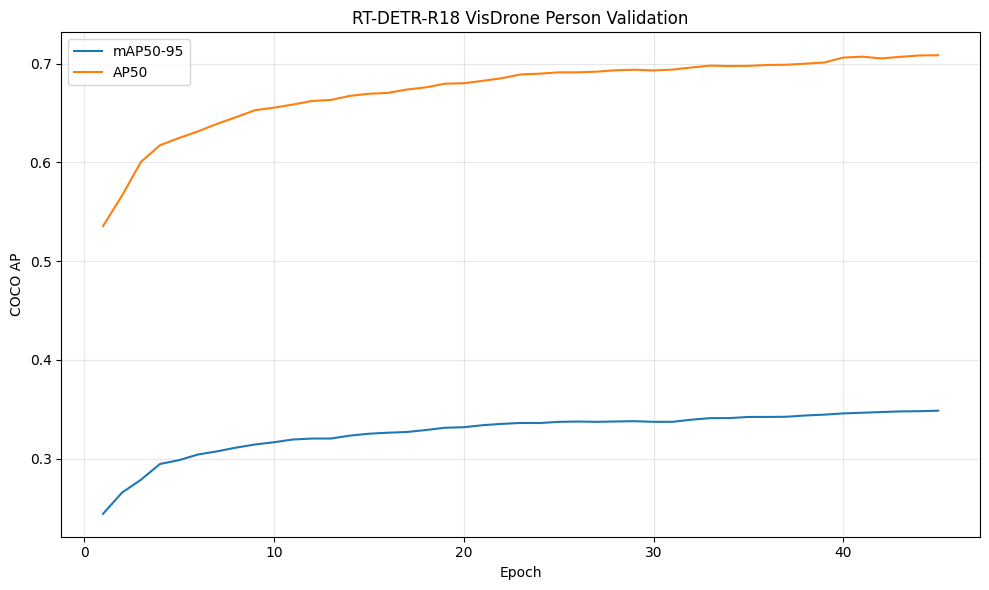


STEP-3 RT-DETR-R18 RUN COMPLETE
Run directory : /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280
Last model    : /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280/last.pth
Best model    : /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280/best.pth
Metrics CSV   : /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280/reports/epoch_metrics.csv
Final report  : /content/drive/MyDrive/aerial_human_detection/step3/rtdetr_r18_visdrone_person_45e_1280/reports/STEP3_RTDETR_R18_RUN_REPORT.json


In [11]:
# ============================================================
# STEP-3 FINAL REPORT ARTIFACTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


if not LOG_FILE.exists():
    raise FileNotFoundError(
        f"RT-DETR log file not found: {LOG_FILE}"
    )

records = []
for line in LOG_FILE.read_text(
    encoding="utf-8"
).splitlines():
    line = line.strip()
    if not line:
        continue
    try:
        records.append(json.loads(line))
    except json.JSONDecodeError:
        pass

if not records:
    raise RuntimeError(
        "No valid epoch records were found in log.txt."
    )

df = pd.DataFrame(records)
df = df.sort_values("epoch").drop_duplicates(
    subset=["epoch"],
    keep="last",
)

METRICS_CSV = REPORT_DIR / "epoch_metrics.csv"
df.to_csv(METRICS_CSV, index=False)

print("Logged epochs:", len(df))
print("Columns:")
print(list(df.columns))

# Locate the COCO bbox metric column.
bbox_metric_column = None
for candidate in [
    "test_coco_eval_bbox",
    "test_coco_eval_bbox_stats",
]:
    if candidate in df.columns:
        bbox_metric_column = candidate
        break

# Fallback to any test column containing coco and bbox.
if bbox_metric_column is None:
    for col in df.columns:
        low = col.lower()
        if col.startswith("test_") and "coco" in low and "bbox" in low:
            bbox_metric_column = col
            break

metric_rows = []

if bbox_metric_column is not None:
    for _, row in df.iterrows():
        stats = row[bbox_metric_column]
        if isinstance(stats, str):
            try:
                stats = json.loads(stats)
            except Exception:
                stats = None

        if isinstance(stats, (list, tuple)) and len(stats) >= 12:
            metric_rows.append(
                {
                    "epoch": int(row["epoch"]) + 1,
                    "mAP50_95": float(stats[0]),
                    "AP50": float(stats[1]),
                    "AP75": float(stats[2]),
                    "AP_small": float(stats[3]),
                    "AP_medium": float(stats[4]),
                    "AP_large": float(stats[5]),
                    "AR_1": float(stats[6]),
                    "AR_10": float(stats[7]),
                    "AR_100": float(stats[8]),
                    "AR_small": float(stats[9]),
                    "AR_medium": float(stats[10]),
                    "AR_large": float(stats[11]),
                }
            )

metrics_df = pd.DataFrame(metric_rows)

SUMMARY_METRICS_CSV = REPORT_DIR / "coco_metrics_summary.csv"
if not metrics_df.empty:
    metrics_df.to_csv(
        SUMMARY_METRICS_CSV,
        index=False,
    )

    best_idx = metrics_df["mAP50_95"].idxmax()
    best_metrics = metrics_df.loc[best_idx].to_dict()

    print("\nBest validation metrics:")
    print(best_metrics)

    # Validation curves.
    fig = plt.figure(figsize=(10, 6))
    plt.plot(
        metrics_df["epoch"],
        metrics_df["mAP50_95"],
        label="mAP50-95",
    )
    plt.plot(
        metrics_df["epoch"],
        metrics_df["AP50"],
        label="AP50",
    )
    plt.xlabel("Epoch")
    plt.ylabel("COCO AP")
    plt.title("RT-DETR-R18 VisDrone Person Validation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    CURVE_FILE = REPORT_DIR / "validation_ap_curves.png"
    plt.savefig(
        CURVE_FILE,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
else:
    best_metrics = {}
    CURVE_FILE = None
    print(
        "WARNING: COCO metric list was not found in the expected log column. "
        "The raw official RT-DETR log is still preserved."
    )

# Checkpoint hashes.
hashes = {
    "last_pth_sha256": sha256_file(LAST_CHECKPOINT),
    "best_pth_sha256": sha256_file(BEST_CHECKPOINT),
    "config_sha256": sha256_file(CONFIG_PATH),
}

hash_file = AUDIT_DIR / "SHA256_CHECKPOINTS.json"
hash_file.write_text(
    json.dumps(hashes, indent=2),
    encoding="utf-8",
)

final_report = {
    "report_generated_at": datetime.now().isoformat(),
    "step": 3,
    "architecture": "RT-DETR-R18",
    "implementation": "Official lyuwenyu/RT-DETR repository, rtdetrv2_pytorch using RT-DETR v1 R18 config",
    "official_repository": OFFICIAL_RTDETR_REPO,
    "official_repository_commit": pinned_commit,
    "pretrained_checkpoint": PRETRAINED_R18_URL,
    "pretrained_dataset": "COCO",
    "training_dataset": "VisDrone2019-DET",
    "dataset_source": "Ultralytics GitHub release assets",
    "visdrone_train_url": VISDRONE_TRAIN_URL,
    "visdrone_val_url": VISDRONE_VAL_URL,
    "class_mapping": {
        "VisDrone category 1 pedestrian": "person",
        "VisDrone category 2 people": "person",
    },
    "num_classes": 1,
    "class_names": ["person"],
    "train_images": train_stats["images"],
    "val_images": val_stats["images"],
    "train_person_instances": train_stats["person_instances"],
    "val_person_instances": val_stats["person_instances"],
    "epochs": EPOCHS,
    "completed_epochs": last_epoch + 1,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "val_batch_size": VAL_BATCH_SIZE,
    "seed": SEED,
    "amp": USE_AMP,
    "optimizer": "AdamW from official RT-DETR R18 config",
    "checkpoint_frequency_epochs": 1,
    "checkpoint_storage": "Google Drive",
    "resume_supported": True,
    "gpu": torch.cuda.get_device_name(0),
    "gpu_memory_gb": round(
        torch.cuda.get_device_properties(0).total_memory / (1024 ** 3),
        3,
    ),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "ultralytics_version": ultralytics.__version__,
    "final_test_used": False,
    "private_final_test_required_for_step3": False,
    "best_validation_metrics": best_metrics,
    "last_checkpoint": str(LAST_CHECKPOINT),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "metrics_csv": str(METRICS_CSV),
    "coco_summary_csv": (
        str(SUMMARY_METRICS_CSV)
        if SUMMARY_METRICS_CSV.exists()
        else None
    ),
    "curve_file": (
        str(CURVE_FILE)
        if CURVE_FILE is not None
        else None
    ),
    "sha256": hashes,
}

FINAL_REPORT_JSON = REPORT_DIR / "STEP3_RTDETR_R18_RUN_REPORT.json"
FINAL_REPORT_JSON.write_text(
    json.dumps(
        final_report,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("\n" + "=" * 88)
print("STEP-3 RT-DETR-R18 RUN COMPLETE")
print("=" * 88)
print("Run directory :", RUN_DIR)
print("Last model    :", LAST_CHECKPOINT)
print("Best model    :", BEST_CHECKPOINT)
print("Metrics CSV   :", METRICS_CSV)
print("Final report  :", FINAL_REPORT_JSON)
print("=" * 88)


## Resume behavior

If Colab disconnects:

1. Reopen this same notebook.
2. Use the same Google Drive.
3. Keep the same `RUN_NAME`.
4. Run the cells again from the top.

VisDrone will be downloaded again to local Colab storage if necessary, but the persistent training state remains in Google Drive. The training cell detects `last.pth` and resumes the official RT-DETR training state instead of starting over.

Do not use the private Final Test during this Step-3 run.
